## HOT Station ALOHA -- Bottle Data

Exploring the Hawaii Ocean Time-series (HOT) bottle data from CMAP to understand its structure, depth range, temporal coverage, and missingness before building any models.

CMAP Table: `tblHOT_Bottle_ALOHA`

### Import Packages

In [1]:
import pycmap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

import statsmodels.api as sm
import tensorflow as tf

# ── Helpers ──────────────────────────────────────────────────────────\
# compute R²
def r2_score(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

def denorm(y_norm):
    return y_norm * y_std + y_mean

In [2]:
import os
os.getcwd()

'/Users/egank31/Documents/Documents - Otto/ml_cbiomes/tutorials/neural_networks_missing_data'

### CMAP Query

In [3]:
# api = pycmap.API(token='<YOUR TOKEN HERE>') ### Edit API Key

# table_name = 'tblHOT_Bottle_ALOHA'
# df = api.query(f"""
#     SELECT * FROM {table_name}
#     WHERE depth BETWEEN 0 AND 30
#     ORDER BY time
# """)

# df.to_csv('hot_aloha_25m_full.csv', index=False)
df = pd.read_csv('../../data/hot_aloha/hot_aloha_25m_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(17391, 68)
['time', 'lat', 'lon', 'depth', 'cruise_name', 'date_time', 'botid', 'press', 'theta', 'sigma', 'temp', 'csal', 'coxy', 'bsal', 'boxy', 'dic', 'ph', 'alk', 'phos', 'nit', 'sil', 'dop', 'don', 'doc', 'tdp', 'tdn', 'pc', 'pn', 'pp', 'lln', 'llp', 'chl', 'phaeo', 'chl3', 'chl12', 'chlplus', 'perid', 'but19', 'fuco', 'hex19', 'prasino', 'diadino', 'zeaxan', 'chlb', 'hplc', 'chlc4', 'acar', 'bcar', 'caroten', 'chlda', 'viol', 'lutein', 'mvchla', 'dvchla', 'hbact', 'pbact', 'sbact', 'ebact', 'atp', 'n2o', 'psi', 'pe4', 'pe5', 'pe10', 'p15n', 'l12', 'd12', 'no2']
                  time    lat  lon      depth cruise_name  date_time  \
0  1988-10-31T00:00:00  22.75 -158   4.670438      HOT001    15704.0   
1  1988-10-31T00:00:00  22.75 -158  10.632544      HOT001   150832.0   
2  1988-10-31T00:00:00  22.75 -158  25.338332      HOT001   150658.0   
3  1988-11-01T00:00:00  22.75 -158   4.074218      HOT001    63545.0   
4  1988-11-01T00:00:00  22.75 -158   7.651513      HOT001   21353

## EDA

Begin by performing exploratory data analysis so that you have an expectation of how the data are structured and can make informed choices about which variables to model.


### Check Depth and Time Range
Confirm that our query returned the expected spatiotemporal coverage.

In [4]:
print(f'Depth range: {df["depth"].min():.1f} to {df["depth"].max():.1f} m')
print(f'Depth mean:  {df["depth"].mean():.1f} m')
print(f'Depth std:   {df["depth"].std():.1f} m')

df['time'] = pd.to_datetime(df['time'])
print(f'\nTime range: {df["time"].min()} to {df["time"].max()}')
print(f'Number of unique dates: {df["time"].dt.date.nunique()}')
print(f'\nLat: {df["lat"].unique()}')
print(f'Lon: {df["lon"].unique()}')

Depth range: 0.3 to 29.9 m
Depth mean:  15.0 m
Depth std:   9.4 m

Time range: 1988-10-31 00:00:00 to 2022-09-03 00:00:00
Number of unique dates: 1007

Lat: [22.75]
Lon: [-158]


### Variable Descriptions
CMAP stores metadata for each variable.
Before exploring the data, let's see what we're working with.

In [5]:
# skip_cols = ['time', 'lat', 'lon', 'depth', 'cruise_name', 'date_time', 'botid', 'press']
# variables = [col for col in df.columns if col not in skip_cols]

# keep_cols = ['Variable', 'Long_Name', 'Unit', 'Sensor', 'Comment']

# meta_rows = []
# for var in variables:
#     try:
#         row = api.get_metadata('tblHOT_Bottle_ALOHA', var)
#         meta_rows.append(row[keep_cols].iloc[[0]])  # just the first non-NaN row
#     except Exception as e:
#         print(f"Skipped {var}: {e}")

# meta = pd.concat(meta_rows, ignore_index=True)

# with pd.option_context('display.max_rows', None):
#     display(meta)

### Missingness

The HOT program has sampled Station ALOHA roughly monthly since October 1988, but not every variable is measured on every cast or every cruise.
Before selecting variables for modeling, we need to understand which variables have enough data to work with.

Total measured variables: 60
Variables with >90% of rows missing: 52
Variables with <50% of rows missing: 5



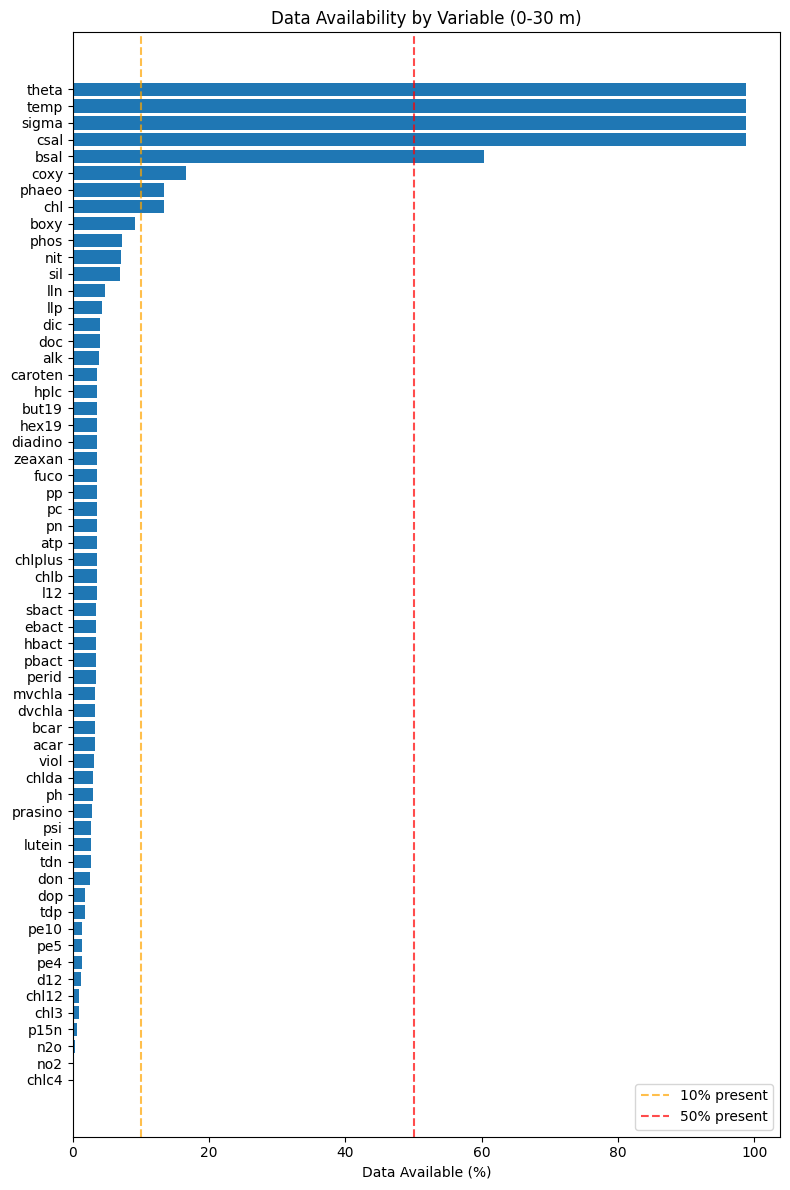

In [6]:
# ── Missingness by variable ──────────────────────────────────────────
meta_cols = ['time', 'lat', 'lon', 'depth', 'cruise_name', 'date_time', 'botid', 'press']
var_cols  = [c for c in df.columns if c not in meta_cols]

miss = df[var_cols].isna().mean().sort_values(ascending=False) * 100
print(f"Total measured variables: {len(var_cols)}")
print(f"Variables with >90% of rows missing: {(miss > 90).sum()}")
print(f"Variables with <50% of rows missing: {(miss < 50).sum()}\n")

# Data availability for each variable
avail_pct = (100 - miss).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(avail_pct.index, avail_pct.values)
ax.axvline(10, color='orange', linestyle='--', alpha=0.7, label='10% present')
ax.axvline(50, color='red',    linestyle='--', alpha=0.7, label='50% present')
ax.set_xlabel('Data Available (%)')
ax.set_title('Data Availability by Variable (0-30 m)')
ax.legend()
plt.tight_layout()
plt.show()

Most variables are >90% missing at the row level.
What matters for us is which variables have enough data to work with and where the gaps are.

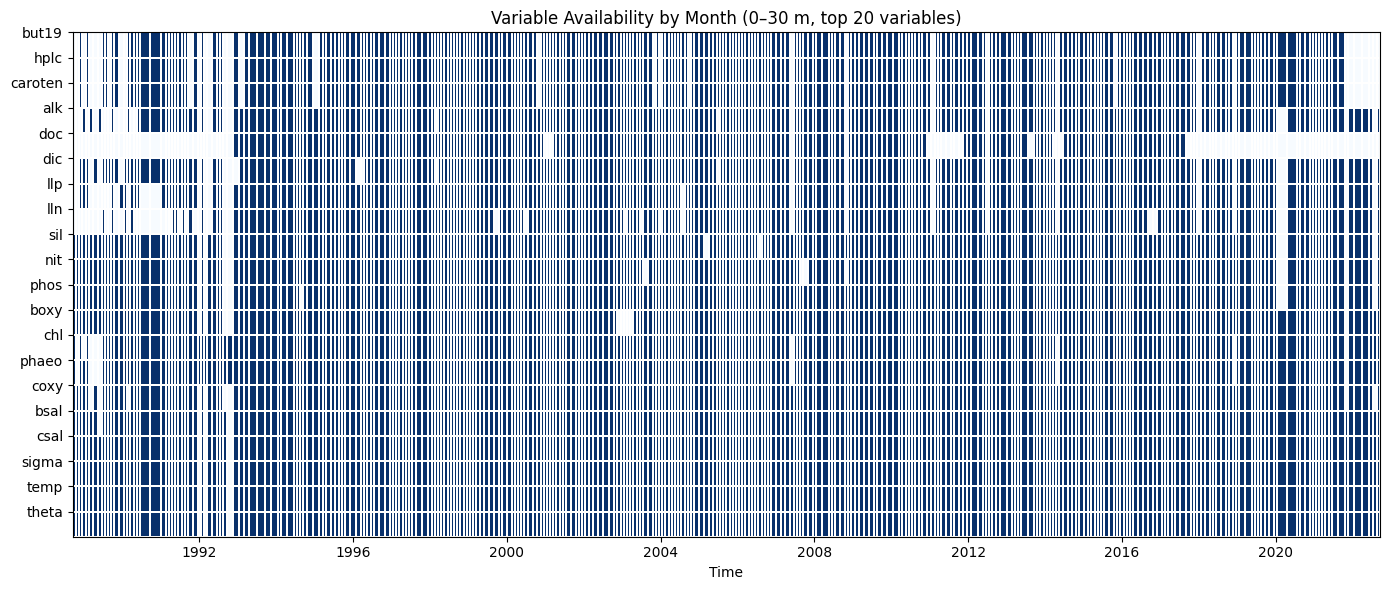

In [7]:
# ── Heatmap: observation availability over time ──────────────────────
# Bin by year-month so each cell = "was this variable measured that month?"
df['ym'] = df['time'].dt.to_period('M')

# Focus on the 20 least-missing variables
top_vars = miss.sort_values(ascending=True).index[:20].tolist()

avail = df.groupby('ym')[top_vars].apply(lambda g: g.notna().any()).astype(int)
avail.index = avail.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
ax.pcolormesh(avail.index, range(len(top_vars)), avail.values.T,
              cmap='Blues', edgecolors='white', linewidth=0.3)
ax.set_yticks(np.arange(len(top_vars)) + 0.5)
ax.set_yticklabels(top_vars)
ax.set_xlabel('Time')
ax.set_title('Variable Availability by Month (0–30 m, top 20 variables)')
plt.tight_layout()
plt.show()

### Correlation Structure

We compute pairwise correlations for variables with sufficient observations. Look for variable pairs with strong positive or negative correlations.
These suggest that one variable could be predicted from another, especially when the predictor is well-sampled and the target is sparse.

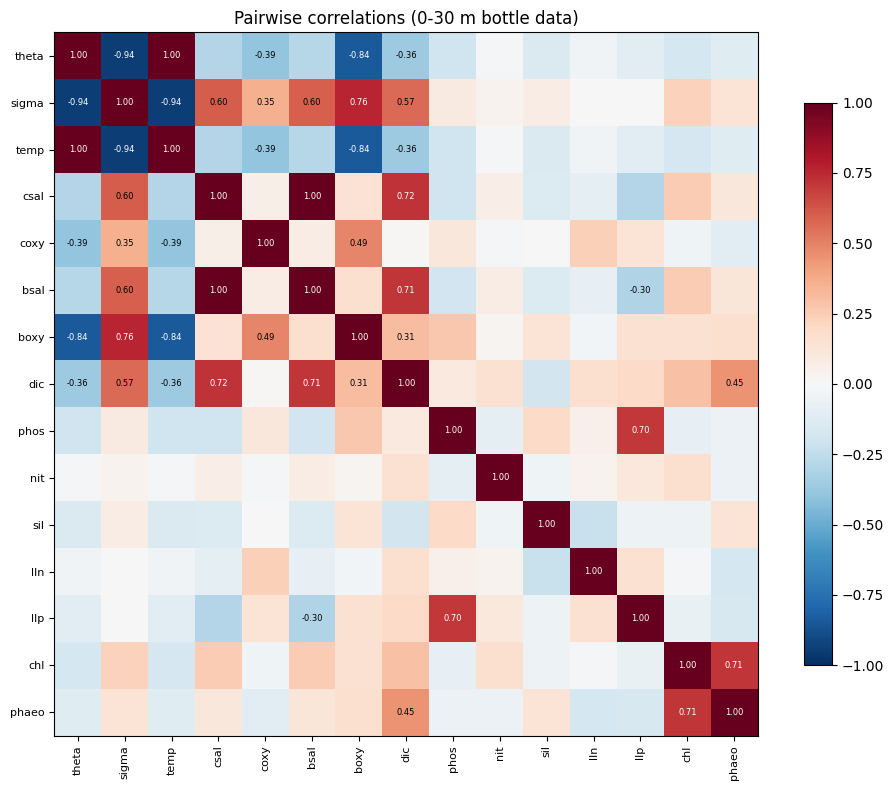

In [8]:
# ── Correlation matrix of well-sampled variables ─────────────────────
# candidates = ['temp', 'csal', 'coxy', 'phos', 'nit', 'sil', 'chl',
#               'phaeo', 'dic', 'alk', 'doc', 'pc', 'pn', 'pp']
min_obs = df['dic'].notna().sum() # Number of DIC observations 
candidates = [c for c in var_cols if df[c].notna().sum() >= min_obs]

# Use only rows where each pair is both present
corr = df[candidates].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(candidates)))
ax.set_xticklabels(candidates, rotation=90, fontsize=8)
ax.set_yticks(range(len(candidates)))
ax.set_yticklabels(candidates, fontsize=8)
for i in range(len(candidates)):
    for j in range(len(candidates)):
        val = corr.iloc[i, j]
        if abs(val) > 0.3:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(val) > 0.7 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Pairwise correlations (0-30 m bottle data)')
plt.tight_layout()
plt.show()

<!-- Salinity and DIC are strongly correlated (r=0.72), and temperature adds additional information (r=-0.36 with DIC).
DIC is scientifically important as a measure of ocean carbon, and it has only 705 observations compared to ~17,000 for temperature and salinity.
This makes DIC prediction from temp and csal a natural demonstration: can we use the nearly complete physical measurements to fill in the sparsely observed carbon chemistry?-->
Look for variable pairs with strong positive or negative correlations.
These suggest that one variable could be predicted from another, especially when the predictor is well-sampled and the target is sparse.
Which variables would make good predictors, and which are worth trying to reconstruct?


In [9]:
print(f"DIC & phaeo co-occurrences: {df[['dic', 'phaeo']].dropna().shape[0]}")
print(f"DIC & temp co-occurrences:  {df[['dic', 'temp']].dropna().shape[0]}")

DIC & phaeo co-occurrences: 171
DIC & temp co-occurrences:  705


Several variables show strong correlations with DIC: `csal` (r=0.72), `temp` (r=-0.36), `phaeo` (r=0.45). However, adding `phaeo` as a predictor reduces the available training data from 705 to 171 rows, since both predictor and target must be present.
`temp` and `csal` are nearly complete, making them practical predictors for reconstructing DIC from routine CTD measurements.

### Exercise: Explore Your Variables

Using the correlation matrix and availability plot above, choose a target variable and one or more predictors. Think about:

- Which variables are well-sampled enough to serve as predictors?
- Which target variable is scientifically interesting but sparse?
- Do the predictor-target correlations suggest a relationship worth modeling?

Plot the time-series of your chosen variables and scatter plots of each predictor against the target.
How many complete rows do you have when all your chosen variables are present?

### Temporal coverage


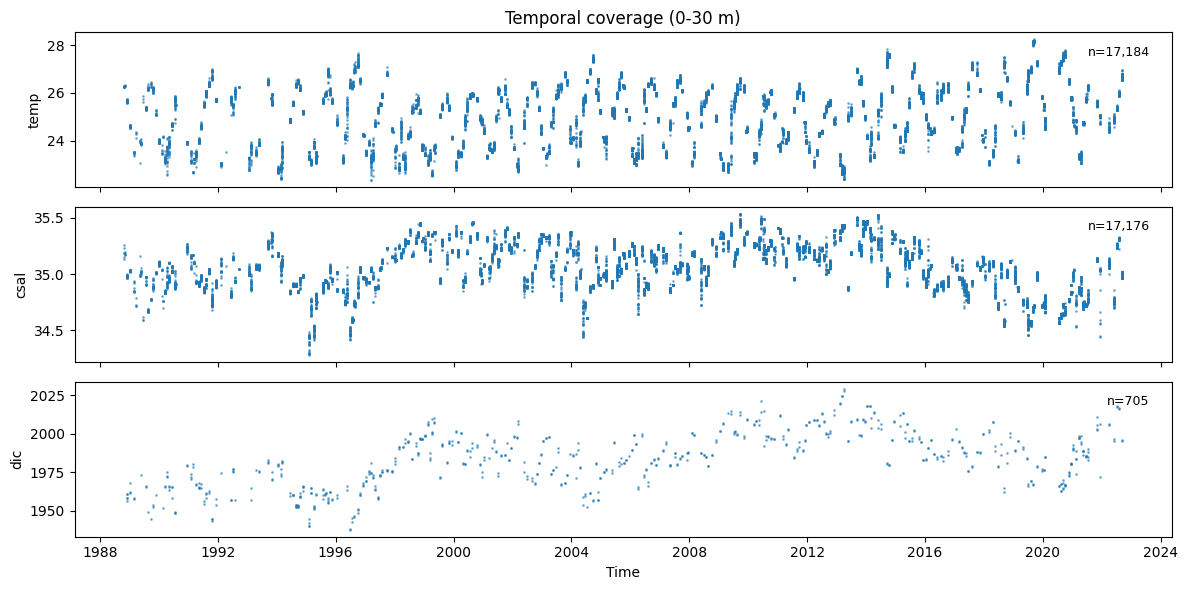

In [10]:
# ── Temporal coverage of predictor and target variables ──────────────
candidates = ['temp', 'csal', 'dic']
fig, axes = plt.subplots(len(candidates), 1, figsize=(12, 6), sharex=True)
for ax, var in zip(axes, candidates):
    mask = df[var].notna()
    ax.scatter(df.loc[mask, 'time'], df.loc[mask, var], s=1, alpha=0.5)
    ax.set_ylabel(var)
    n = mask.sum()
    ax.text(0.98, 0.85, f'n={n:,}', transform=ax.transAxes, ha='right', fontsize=9)
axes[-1].set_xlabel('Time')
axes[0].set_title('Temporal coverage (0-30 m)')
plt.tight_layout()
plt.show()

All three variables span the full 1988-2022 record. DIC observations are scattered throughout rather than concentrated in any single period, which is important for training a model that generalizes across the full time range.

### Predictor-target overlap

In [11]:
# ── Overlap: rows where predictors and target are all present ────────
cols = ['temp', 'csal', 'dic']
n = df[cols].notna().all(axis=1).sum()
print(f"Rows with temp, csal, and dic all present: {n:,}")

Rows with temp, csal, and dic all present: 705


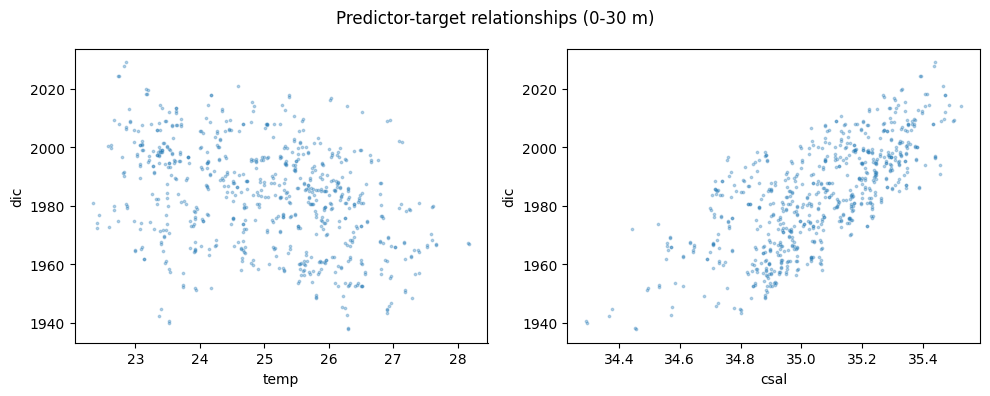

In [12]:
# ── Predictor-target relationships ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

mask = df[['temp', 'csal', 'dic']].notna().all(axis=1)
sub = df.loc[mask]

axes[0].scatter(sub['temp'], sub['dic'], s=3, alpha=0.3)
axes[0].set_xlabel('temp')
axes[0].set_ylabel('dic')

axes[1].scatter(sub['csal'], sub['dic'], s=3, alpha=0.3)
axes[1].set_xlabel('csal')
axes[1].set_ylabel('dic')

plt.suptitle('Predictor-target relationships (0-30 m)')
plt.tight_layout()
plt.show()

## Preparing Training Data

### Feature Engineering

Day-of-year is encoded cyclically as sin and cos so that the network understands that December and January are adjacent, not 365 days apart.

In [13]:
df['doy_sin'] = np.sin(2 * np.pi * df['time'].dt.dayofyear / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['time'].dt.dayofyear / 365)

# ── Prepare training data ────────────────────────────────────────────
predictors = ['temp', 'csal', 'doy_sin', 'doy_cos']
target = 'dic'

### Train/Test Split

We keep only rows where all selected variables are present, then randomly shuffle and split 80/20 into training and test sets.
Because we are predicting from co-located measurements (not forecasting into the future), random splitting is appropriate here.
The model learns from the training set and is evaluated on held-out data it has never seen.

In [14]:
mask = df[predictors + [target]].notna().all(axis=1)
data = df.loc[mask, predictors + [target]].values.copy()
print(f"Complete rows: {len(data):,}")

# Shuffle data
rng = np.random.default_rng(42)
data = data[rng.permutation(len(data))]

# Define split sizes
n_total = len(data)
n_train = int(0.7 * n_total)
n_val   = int(0.15 * n_total)

# Split indices
train_data = data[:n_train]
val_data   = data[n_train:n_train + n_val]
test_data  = data[n_train + n_val:]

# Split into X and y
X_train = train_data[:, :len(predictors)]
y_train = train_data[:, len(predictors):]

X_val = val_data[:, :len(predictors)]
y_val = val_data[:, len(predictors):]

X_test = test_data[:, :len(predictors)]
y_test = test_data[:, len(predictors):]

print(f"Train: {X_train.shape[0]:,}")
print(f"Val:   {X_val.shape[0]:,}")
print(f"Test:  {X_test.shape[0]:,}")

Complete rows: 705
Train: 493
Val:   105
Test:  107


#### Normalization

Neural networks train more effectively when inputs and targets have similar scales.
We subtract the mean and divide by the standard deviation, computed from the training set only.
The test set is normalized using the same training statistics to avoid data leakage.

In [15]:
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
y_mean, y_std = y_train.mean(), y_train.std()

X_train_n = (X_train - X_mean) / X_std
X_val_n = (X_val - X_mean) / X_std
X_test_n  = (X_test  - X_mean) / X_std
y_train_n = (y_train - y_mean) / y_std
y_val_n = (y_val - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

print(f"X_mean = {X_mean}")
print(f"X_std  = {X_std}")
print(f"y_mean = {y_mean:.2f}, y_std = {y_std:.2f}")


X_mean = [25.06597647 35.05808032 -0.03649197 -0.04954794]
X_std  = [1.24578088 0.21989257 0.70445722 0.7070738 ]
y_mean = 1982.97, y_std = 17.50


### Linear Regression Baseline
Before building a neural network, we fit a simple linear regression to establish a baseline.
If a linear model already performs well, the added complexity of an ANN may not be justified.

In [16]:
### Linear Regression Baseline
model_lr = sm.OLS(y_train_n, sm.add_constant(X_train_n)).fit()
print(model_lr.summary())

# Test set performance
# Predictions (normalized → original scale)
y_pred_lr_test = model_lr.predict(sm.add_constant(X_test_n))
y_pred_lr = y_pred_lr_test * y_std + y_mean

# Metrics (original scale)
lr_r2_test = r2_score(y_test, y_pred_lr)
lr_rmse_test = np.sqrt(np.mean((y_test.flatten() - y_pred_lr.flatten())**2))

print(f"\nTest R² (LR):  {lr_r2_test:.4f}")
print(f"Test RMSE (LR): {lr_rmse_test:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     178.9
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           3.18e-94
Time:                        15:07:05   Log-Likelihood:                -477.01
No. Observations:                 493   AIC:                             964.0
Df Residuals:                     488   BIC:                             985.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.659e-15      0.029  -1.62e-13      1.0

The linear model explains ~49% of test variance.
The gap between train and test $R^2$ is small, suggesting the model is underfitting rather than overfitting.
Can a neural network capture additional nonlinear structure?

### Building the Network

We build a simple feedforward network.
The architecture, learning rate, and training duration can all be adjusted.
Start simple and add capacity only if the model is underfitting.

#### Hyperparameters

A wider layer (more neurons) lets the network represent more complex relationships.
Deeper networks (more layers) can learn hierarchical patterns.
Start simple and add capacity only if the training loss suggests the model is underfitting.
If the gap between training and test loss grows, the network is too large for the available data.

In [17]:
# # ── Hyperparameter search ────────────────────────────────────────────
# import tensorflow as tf
# from itertools import product

# param_grid = {
#     'hidden': [[16], [32], [64], [128], [64, 64]],
#     'lr': [1e-3, 5e-4],
# }

# X_train_t = tf.constant(X_train_n, dtype=tf.float32)
# X_test_t = tf.constant(X_test_n, dtype=tf.float32)
# y_train_t = tf.constant(y_train_n, dtype=tf.float32)
# y_test_t = tf.constant(y_test_n, dtype=tf.float32)

# configs = list(product(param_grid['hidden'], param_grid['lr']))
# print(f'Testing {len(configs)} configurations...\n')

# results = []
# for i, (hidden, lr) in enumerate(configs):
#     tf.random.set_seed(42)
#     np.random.seed(42)
    
#     model = tf.keras.Sequential()
#     model.add(tf.keras.layers.Input(shape=(len(predictors),)))
#     for units in hidden:
#         model.add(tf.keras.layers.Dense(units, activation='relu'))
#     model.add(tf.keras.layers.Dense(1))
    
#     model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    
#     hist = model.fit(
#         X_train_t, y_train_t,
#         validation_data=(X_test_t, y_test_t),
#         epochs=500, batch_size=64, verbose=0,
#         callbacks=[tf.keras.callbacks.EarlyStopping(
#             patience=50, restore_best_weights=True, monitor='val_loss'
#         )]
#     )
    
#     best_val = min(hist.history['val_loss'])
#     n_epochs = len(hist.history['loss'])
#     results.append({'hidden': hidden, 'lr': lr, 'val_loss': best_val, 'epochs': n_epochs})
#     print(f'[{i+1}/{len(configs)}] hidden={str(hidden):16s} lr={lr:.0e}  '
#           f'val_loss={best_val:.6f}  epochs={n_epochs}')

# results_df = pd.DataFrame(results).sort_values('val_loss')
# print(f'\nTop 5 configurations:')
# print(results_df.head().to_string(index=False))


In [18]:
# ── Hyperparameters ──────────────────────────────────────────────────
### A wider layer (more neurons) lets the network represent more complex relationships.
### Deeper networks (more layers) can learn hierarchical patterns.
### Start simple and add capacity only if the training loss suggests the model is underfitting.
### If the gap between training and test loss grows, the network is too large for the available data.
hidden_layers = [64, 64]   # try [32], [128], [64, 64, 64], etc.
learning_rate = 1e-3       # Adam learning rate
n_epochs      = 500        # maximum training epochs
patience      = 50         # stop if val_loss doesn't improve for this many epochs
batch_size    = 64         # number of samples per gradient update

#### Build and Compile

We construct a feedforward network using `tf.keras.Sequential`.
Each hidden layer uses an activation function.
The output layer is linear (no activation) because we are predicting a continuous value.
The network is compiled with the Adam optimizer and mean squared error loss.

In [19]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

# ── Build the network ────────────────────────────────────────────────
model = tf.keras.Sequential()
# ── Input layer ──────────────────────────────────────────────────────
model.add(tf.keras.layers.Input(shape=(len(predictors),)))
# ── Add hidden layers ────────────────────────────────────────────────
model.add(tf.keras.layers.Dense(hidden_layers[0], activation='relu',
                                 kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)))
model.add(tf.keras.layers.Dense(hidden_layers[1], activation='relu',
                                 kernel_initializer=tf.keras.initializers.GlorotUniform(seed=43)))
# ── Output layer ─────────────────────────────────────────────────────
model.add(tf.keras.layers.Dense(1, activation='linear',
                                 kernel_initializer=tf.keras.initializers.GlorotUniform(seed=44)))
# ── Compile: choose optimizer and loss function ──────────────────────
nn_optimizer = tf.keras.optimizers.Adam(learning_rate)
nn_loss = 'mse'
model.compile(
    optimizer=nn_optimizer,
    loss=nn_loss
)

print(f"Architecture: {len(predictors)} -> {' -> '.join(str(h) for h in hidden_layers)} -> 1")

Architecture: 4 -> 64 -> 64 -> 1


#### Train and Evaluate

Use `model.fit()` to train the network.
Pass in the training data, validation data, and an `EarlyStopping` callback that monitors `val_loss`.

In [20]:
# ── Tensors ──────────────────────────────────────────────────────────
X_train_t = tf.constant(X_train_n, dtype=tf.float32)
X_val_t   = tf.constant(X_val_n,   dtype=tf.float32)
X_test_t  = tf.constant(X_test_n,  dtype=tf.float32)

y_train_t = tf.constant(y_train_n, dtype=tf.float32)
y_val_t   = tf.constant(y_val_n,   dtype=tf.float32)
y_test_t  = tf.constant(y_test_n,  dtype=tf.float32)

# ── Train ────────────────────────────────────────────────────────────
hist = model.fit(
    X_train_t, y_train_t,
    validation_data=(X_val_t, y_val_t),
    epochs=n_epochs,
    batch_size=batch_size,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=patience,
        restore_best_weights=True,
        monitor='val_loss'
    )]
)

# ── Predictions (original scale) ─────────────────────────────────────
pred_train = denorm(model.predict(X_train_t, verbose=0))
pred_val   = denorm(model.predict(X_val_t,   verbose=0))
pred_test  = denorm(model.predict(X_test_t,  verbose=0))

# ── Metrics ──────────────────────────────────────────────────────────
r2_train = r2_score(y_train, pred_train)
r2_val   = r2_score(y_val,   pred_val)
r2_test  = r2_score(y_test,  pred_test)

rmse_test = np.sqrt(np.mean((y_test.flatten() - pred_test.flatten())**2))

# ── Report ───────────────────────────────────────────────────────────
print(f"Stopped at epoch: {len(hist.history['loss'])}")
print(f"Best val loss:    {min(hist.history['val_loss']):.6f}\n")

print(f"Train R²: {r2_train:.4f}")
print(f"Val   R²: {r2_val:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")

Stopped at epoch: 410
Best val loss:    0.277688

Train R²: 0.8757
Val   R²: 0.7433
Test  R²: 0.6539
Test RMSE: 10.5246


#### Training Curve

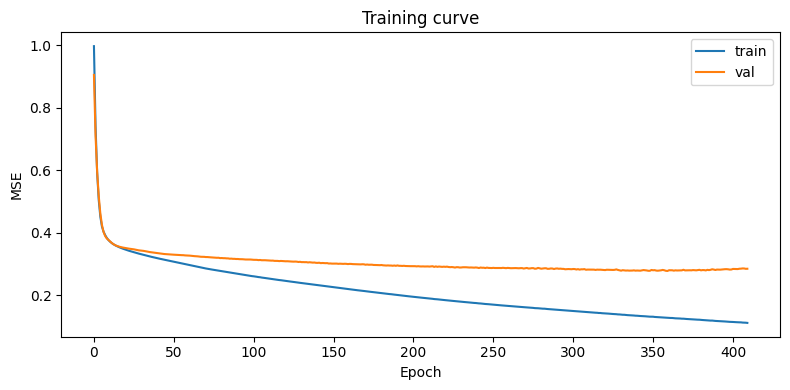

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist.history['loss'], label='train')
ax.plot(hist.history['val_loss'], label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Training curve')
ax.legend()
plt.tight_layout()
plt.show()

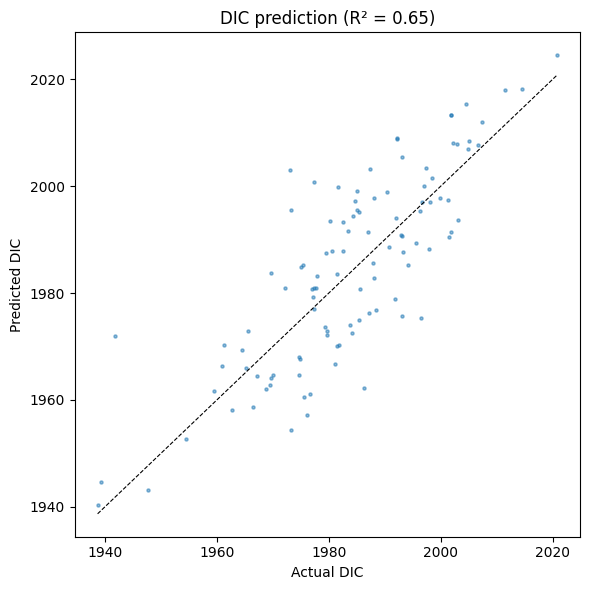

In [22]:
# ── Predicted vs actual ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pred_test, y_test, s=5, alpha=0.5)
lo, hi = pred_test.min(), pred_test.max()
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
ax.set_xlabel('Actual DIC')
ax.set_ylabel('Predicted DIC')
ax.set_title(f'DIC prediction (R² = {r2_test:.2f})')
plt.tight_layout()
plt.show()

$R^2 = 0.65$ means the network captures about two-thirds of the DIC variability from physical measurements alone.
The predicted vs. observed plot follows the general trend across the full range of observed DIC values, but with considerable scatter.
The remaining variance reflects processes that temperature and salinity alone cannot capture.

### Gap-filling
With the trained network, we can estimate DIC for every row where temperature and salinity exist but DIC was not measured.

In [23]:
# ── Fill missing DIC ─────────────────────────────────────────────────
has_predictors = df[predictors].notna().all(axis=1)
missing_dic = df['dic'].isna()
to_fill = has_predictors & missing_dic

X_fill = df.loc[to_fill, predictors].values
X_fill_n = (X_fill - X_mean) / X_std
pred_fill_n = model.predict(tf.constant(X_fill_n, dtype=tf.float32), verbose=0)
pred_fill = pred_fill_n * y_std + y_mean

print(f"Rows with predictors but missing DIC: {to_fill.sum():,}")
print(f"Predicted DIC range: {pred_fill.min():.1f} to {pred_fill.max():.1f}")
print(f"Training DIC range:  {y_train.min():.1f} to {y_train.max():.1f}")

Rows with predictors but missing DIC: 16,471
Predicted DIC range: 1930.4 to 2026.1
Training DIC range:  1937.7 to 2027.6


The trained network can now estimate DIC for every row where temperature and salinity exist, filling in 16,471 observations that lack direct DIC measurements.
The predicted range (1938-2024) does not fully reach the highest observed training values (2029), suggesting the network underestimates extremes.

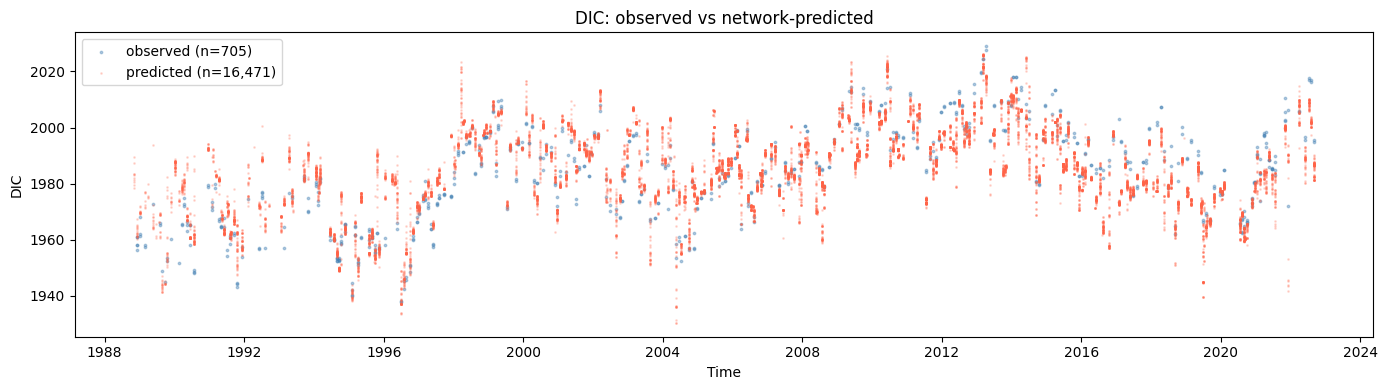

In [24]:
# ── Plot observed vs filled DIC ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# Observed
obs_mask = df['dic'].notna()
ax.scatter(df.loc[obs_mask, 'time'], df.loc[obs_mask, 'dic'], s=3, alpha=0.4,
           color='steelblue', label=f'observed (n={obs_mask.sum():,})')

# Filled
ax.scatter(df.loc[to_fill, 'time'], pred_fill, s=1, alpha=0.2,
           color='tomato', label=f'predicted (n={to_fill.sum():,})')

ax.set_xlabel('Time')
ax.set_ylabel('DIC')
ax.set_title('DIC: observed vs network-predicted')
ax.legend()
plt.tight_layout()
plt.show()


The network fills 16,471 missing DIC values using the nearly complete temperature and salinity record.

### Explore Other Combinations

The same approach can be applied to other target variables.
Use the helper below to check how much training data is available for different predictor/target combinations before rebuilding the model above.

In [25]:
# How much training data would you have for different predictor/target combinations?
def check_overlap(df, predictors, target):
    cols = predictors + [target]
    n = df[cols].notna().all(axis=1).sum()
    print(f"Predictors: {predictors}")
    print(f"Target:     {target}")
    print(f"Complete rows: {n:,}\n")

check_overlap(df, ['temp', 'csal'], 'dic')
check_overlap(df, ['temp', 'csal'], 'coxy')
check_overlap(df, ['temp', 'csal'], 'phos')
check_overlap(df, ['temp', 'csal', 'phaeo'], 'dic')

Predictors: ['temp', 'csal']
Target:     dic
Complete rows: 705

Predictors: ['temp', 'csal']
Target:     coxy
Complete rows: 2,880

Predictors: ['temp', 'csal']
Target:     phos
Complete rows: 1,246

Predictors: ['temp', 'csal', 'phaeo']
Target:     dic
Complete rows: 171

